# IS 584 – Assignment 3
**Dense & Hybrid Retrieval over ISO/IEC 5338 AI Lifecycle Processes**

**Student:** [Your Name]  
**Date:** 2026-05-17

---
## Part 0 – Setup

In [1]:
# Package versions
import sys, os, random, warnings, re, json
import numpy as np
import pandas as pd
import torch
import sentence_transformers
import sklearn
import rank_bm25
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

print(f'Python            : {sys.version.split()[0]}')
print(f'PyTorch           : {torch.__version__}')
print(f'Sentence-Trans.   : {sentence_transformers.__version__}')
print(f'scikit-learn      : {sklearn.__version__}')
print(f'NumPy             : {np.__version__}')
print(f'Pandas            : {pd.__version__}')
print(f'Matplotlib        : {matplotlib.__version__}')


Python            : 3.14.4
PyTorch           : 2.12.0
Sentence-Trans.   : 5.5.0
scikit-learn      : 1.8.0
NumPy             : 2.4.5
Pandas            : 3.0.3
Matplotlib        : 3.10.9


In [2]:
# Random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Random seed set to {SEED}')


Random seed set to 42


In [3]:
# Load corpus
BASE = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, BASE)
from documents import iso_5338_summaries

doc_keys  = list(iso_5338_summaries.keys())
doc_texts = list(iso_5338_summaries.values())
NUM_DOCS  = len(doc_keys)
doc_name_to_idx = {name: i for i, name in enumerate(doc_keys)}

print(f'Corpus size : {NUM_DOCS} documents')
for i, k in enumerate(doc_keys):
    print(f'  [{i:2d}] {k}')


Corpus size : 33 documents
  [ 0] Acquisition Process (6.1.1)
  [ 1] Supply Process (6.1.2)
  [ 2] Life Cycle Model Management Process (6.2.1)
  [ 3] Infrastructure Management Process (6.2.2)
  [ 4] Portfolio Management Process (6.2.3)
  [ 5] Human Resource Management Process (6.2.4)
  [ 6] Quality Management Process (6.2.5)
  [ 7] Knowledge Management Process (6.2.6)
  [ 8] Project Planning Process (6.3.1)
  [ 9] Project Assessment and Control Process (6.3.2)
  [10] Decision Management Process (6.3.3)
  [11] Risk Management Process (6.3.4)
  [12] Configuration Management Process (6.3.5)
  [13] Information Management Process (6.3.6)
  [14] Measurement Process (6.3.7)
  [15] Quality Assurance Process (6.3.8)
  [16] Business or Mission Analysis Process (6.4.1)
  [17] Stakeholder Needs and Requirements Definition Process (6.4.2)
  [18] System Requirements Definition Process (6.4.3)
  [19] System Architecture Definition Process (6.4.4)
  [20] Design Definition Process (6.4.5)
  [21] System

In [4]:
# Load queries
CSV_PATH = os.path.join(BASE, 'td_cases_test_1.csv')
df = pd.read_csv(CSV_PATH, index_col=0)
df['root_cause'] = df['root_cause'].fillna('').replace('-', '')
df['query'] = (df['case_description'].str.strip() + ' ' + df['root_cause'].str.strip()).str.strip()

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print(f'golden_id range: {df["golden_id"].min()} to {df["golden_id"].max()}')
df.head(3)


Dataset shape : (157, 5)
Columns       : ['case_description', 'root_cause', 'golden_doc', 'golden_id', 'query']
golden_id range: 0 to 31


,case_description,root_cause,golden_doc,golden_id,query
0,Having adversarial data,Malicious users are trying to get PII informat...,System Requirements Definition Process (6.4.3),18,Having adversarial data Malicious users are tr...
1,Long and redundant deployment of recommendatio...,,Transition Process (6.4.12),27,Long and redundant deployment of recommendatio...
2,"Failures in automated processes, such as the s...",Reusing of existing model codes with insuffici...,Knowledge Management Process (6.2.6),7,"Failures in automated processes, such as the s..."


In [5]:
# Embed documents with all-MiniLM-L6-v2
from sentence_transformers import SentenceTransformer

MODEL_NAME = 'all-MiniLM-L6-v2'
model = SentenceTransformer(MODEL_NAME)

print(f'Encoding {NUM_DOCS} documents ...')
doc_embeddings = model.encode(doc_texts, convert_to_numpy=True, show_progress_bar=True)
print(f'doc_embeddings : {doc_embeddings.shape}')

print(f'Encoding {len(df)} queries ...')
query_embeddings = model.encode(df['query'].tolist(), convert_to_numpy=True, show_progress_bar=True)
print(f'query_embeddings : {query_embeddings.shape}')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding 33 documents ...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

doc_embeddings : (33, 384)
Encoding 157 queries ...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

query_embeddings : (157, 384)


---
## Part 1 – Data Analysis

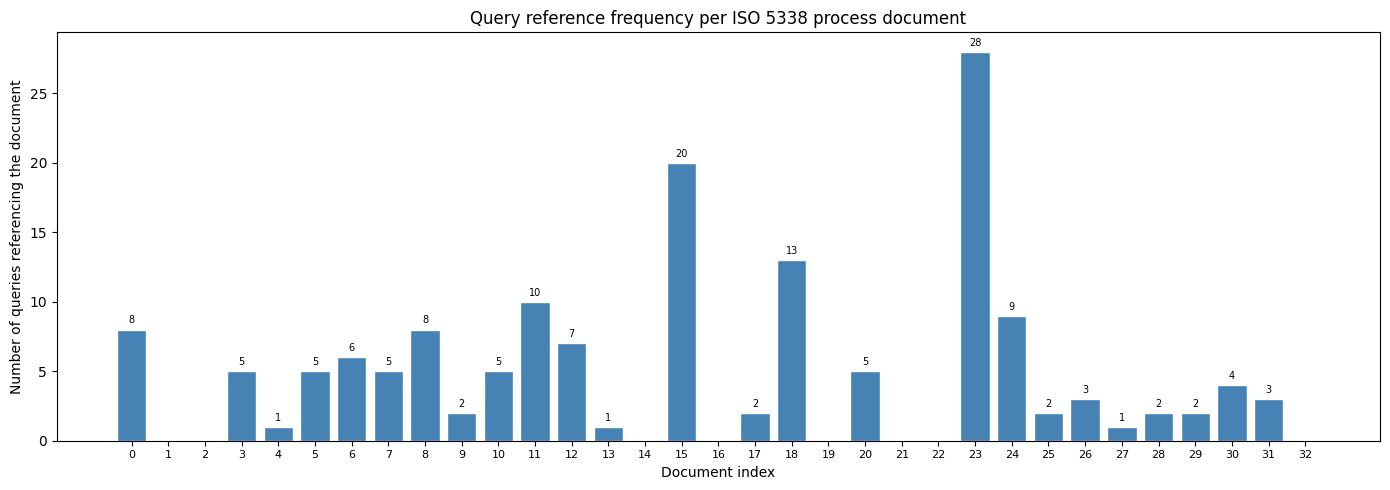

Saved: fig_doc_freq.png


In [6]:
from collections import Counter

doc_freq = Counter(df['golden_id'].tolist())
counts   = [doc_freq.get(i, 0) for i in range(NUM_DOCS)]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(NUM_DOCS), counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(NUM_DOCS))
ax.set_xticklabels([str(i) for i in range(NUM_DOCS)], fontsize=8)
ax.set_xlabel('Document index')
ax.set_ylabel('Number of queries referencing the document')
ax.set_title('Query reference frequency per ISO 5338 process document')
for bar, c in zip(bars, counts):
    if c > 0:
        ax.text(bar.get_x() + bar.get_width()/2, c + 0.3, str(c),
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_doc_freq.png'), dpi=300)
plt.show()
print('Saved: fig_doc_freq.png')


In [7]:
# Documents referenced more than once
multi_ref = [(i, doc_keys[i], doc_freq.get(i,0)) for i in range(NUM_DOCS) if doc_freq.get(i,0) > 1]
print(f'Documents referenced more than once: {len(multi_ref)} / {NUM_DOCS}')
print(f'{"ID":>4}  {"Count":>5}  Process name')
for idx, name, cnt in sorted(multi_ref, key=lambda x: -x[2]):
    print(f'  {idx:2d}    {cnt:4d}  {name}')


Documents referenced more than once: 22 / 33
  ID  Count  Process name
  23      28  AI Data Engineering Process (6.4.8)
  15      20  Quality Assurance Process (6.3.8)
  18      13  System Requirements Definition Process (6.4.3)
  11      10  Risk Management Process (6.3.4)
  24       9  Implementation Process (6.4.9)
   0       8  Acquisition Process (6.1.1)
   8       8  Project Planning Process (6.3.1)
  12       7  Configuration Management Process (6.3.5)
   6       6  Quality Management Process (6.2.5)
   3       5  Infrastructure Management Process (6.2.2)
   5       5  Human Resource Management Process (6.2.4)
   7       5  Knowledge Management Process (6.2.6)
  10       5  Decision Management Process (6.3.3)
  20       5  Design Definition Process (6.4.5)
  30       4  Operation Process (6.4.15)
  26       3  Verification Process (6.4.11)
  31       3  Maintenance Process (6.4.16)
   9       2  Project Assessment and Control Process (6.3.2)
  17       2  Stakeholder Needs and 

In [8]:
# Documents not referenced by any query
no_ref = [i for i in range(NUM_DOCS) if doc_freq.get(i, 0) == 0]
print(f'Documents NOT referenced by any query: {len(no_ref)} / {NUM_DOCS}')
for i in no_ref:
    print(f'  [{i:2d}] {doc_keys[i]}')


Documents NOT referenced by any query: 8 / 33
  [ 1] Supply Process (6.1.2)
  [ 2] Life Cycle Model Management Process (6.2.1)
  [14] Measurement Process (6.3.7)
  [16] Business or Mission Analysis Process (6.4.1)
  [19] System Architecture Definition Process (6.4.4)
  [21] System Analysis Process (6.4.6)
  [22] Knowledge Acquisition Process (6.4.7)
  [32] Disposal Process (6.4.17)


Mean keyword overlap  : 0.114
Median                : 0.091
Std                   : 0.107
Queries with >=1 hit  : 70.7%


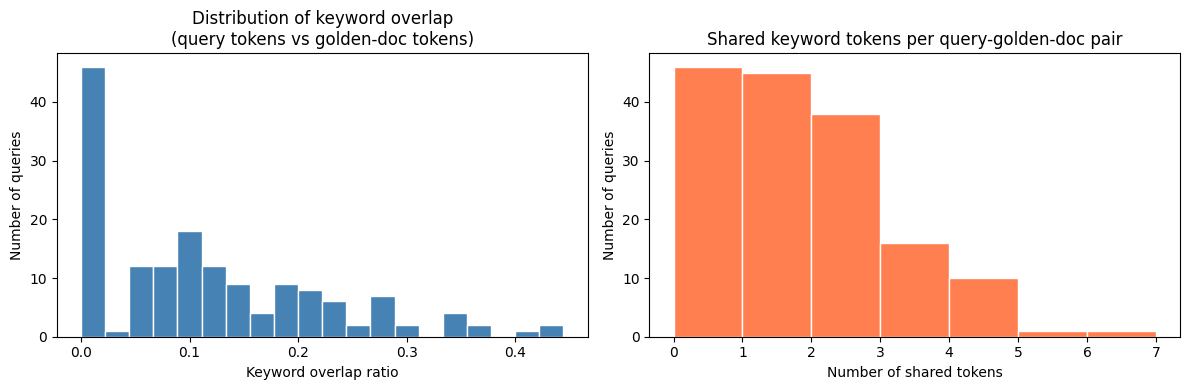

Saved: fig_keyword_overlap.png


In [9]:
# Keyword overlap analysis
STOP = {
    'that', 'this', 'with', 'from', 'have', 'they', 'will', 'been', 'into',
    'more', 'also', 'such', 'when', 'which', 'their', 'each', 'other',
    'system', 'process', 'data', 'model', 'should', 'used', 'using',
    'include', 'requires', 'applied', 'given', 'therefore', 'without',
    'activities', 'tasks', 'outcomes', 'applies', 'defined', 'provides',
    'following', 'processes', 'standard'
}

def tokenize(text):
    return set(re.findall(r'\b[a-z]{4,}\b', text.lower())) - STOP

overlaps, shared_counts = [], []
for _, row in df.iterrows():
    q_tok = tokenize(row['query'])
    d_tok = tokenize(doc_texts[int(row['golden_id'])])
    shared = q_tok & d_tok
    shared_counts.append(len(shared))
    overlaps.append(len(shared) / max(len(q_tok), 1))

df['overlap'] = overlaps
df['shared_tokens'] = shared_counts

print(f'Mean keyword overlap  : {np.mean(overlaps):.3f}')
print(f'Median                : {np.median(overlaps):.3f}')
print(f'Std                   : {np.std(overlaps):.3f}')
print(f'Queries with >=1 hit  : {np.mean([o > 0 for o in overlaps])*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(overlaps, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Keyword overlap ratio')
axes[0].set_ylabel('Number of queries')
axes[0].set_title('Distribution of keyword overlap\n(query tokens vs golden-doc tokens)')
axes[1].hist(shared_counts, bins=range(0, max(shared_counts)+2), color='coral', edgecolor='white')
axes[1].set_xlabel('Number of shared tokens')
axes[1].set_ylabel('Number of queries')
axes[1].set_title('Shared keyword tokens per query-golden-doc pair')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_keyword_overlap.png'), dpi=300)
plt.show()
print('Saved: fig_keyword_overlap.png')


In [10]:
# Sample keyword overlaps
print('Example shared keywords (query vs golden doc):\n')
for _, row in df.sample(5, random_state=42).iterrows():
    q_tok = tokenize(row['query'])
    d_tok = tokenize(doc_texts[int(row['golden_id'])])
    print(f'  Query      : {row["query"][:100]}')
    print(f'  Golden doc : {row["golden_doc"]}')
    print(f'  Shared     : {sorted(q_tok & d_tok)[:10]}')
    print()


Example shared keywords (query vs golden doc):

  Query      : Unable to include the documents exceeding the character size limitations of the embedding model into
  Golden doc : AI Data Engineering Process (6.4.8)
  Shared     : ['datasets', 'documents', 'models']

  Query      : Problems in data retrieval via API, such as incorrect parsing, fetching unnecessary data, and not te
  Golden doc : AI Data Engineering Process (6.4.8)
  Shared     : ['acquisition', 'testing']

  Query      : Having noisy data Scraped commercial websites include duplicate and inconsistent user submission dat
  Golden doc : AI Data Engineering Process (6.4.8)
  Shared     : []

  Query      : Loss of information in experiment details Manual experiement tracking is not systematically done
  Golden doc : Project Planning Process (6.3.1)
  Shared     : []

  Query      : Extended duration of model development because of the usage of spot instances leading to termination
  Golden doc : Infrastructure Management P

### Part 1 – Answers

**Q1: Whether each document is referenced by queries more than once.**

22 out of 33 ISO 5338 process documents are referenced by **more than one** query. The distribution is highly skewed: the top three most-referenced processes are AI Data Engineering (6.4.8) with 28 references, Quality Assurance (6.3.8) with 20, and System Requirements Definition (6.4.3) with 13. This imbalance reflects that real-world AI technical debt accumulates disproportionately around data management and quality assurance activities.

**Q2: Whether there are documents not referenced by any query.**

8 documents are never referenced: Supply Process (6.1.2), Life Cycle Model Management (6.2.1), Measurement Process (6.3.7), Business or Mission Analysis (6.4.1), System Architecture Definition (6.4.4), System Analysis (6.4.6), Knowledge Acquisition (6.4.7), and Disposal Process (6.4.17). These are abstract upstream lifecycle or end-of-life activities rarely described as technical debt by practitioners.

**Q3: Whether queries and their associated documents share keywords or concepts.**

The mean keyword overlap ratio is only **0.114** (median 0.091), meaning a query shares roughly 11% of its non-stopword tokens with its golden document. 70.7% of queries share at least one content keyword, but many share none at all. This vocabulary mismatch is the primary challenge: practitioners describe technical debt in informal, operational language while ISO documents use formal, standards-oriented terminology. This gap motivates both the hybrid BM25 approach and the query rewriting step.

---
## Part 2 – Dense Retrieval

In [11]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

cos_scores   = cos_sim(query_embeddings, doc_embeddings)  # (N, 33)
ranked_dense = np.argsort(-cos_scores, axis=1)
gold_ids     = df['golden_id'].tolist()
print(f'Similarity matrix shape: {cos_scores.shape}')


Similarity matrix shape: (157, 33)


In [12]:
# Metric functions
def hit_at_k(ranked, gold, k):
    return float(np.mean([gold[i] in ranked[i, :k] for i in range(len(gold))]))

def ndcg_at_k(ranked, gold, k):
    scores = []
    for i in range(len(gold)):
        lst = ranked[i, :k].tolist()
        if gold[i] in lst:
            r = lst.index(gold[i]) + 1
            scores.append(1.0 / np.log2(r + 1))
        else:
            scores.append(0.0)
    return float(np.mean(scores))

def get_ranks(ranked, gold):
    return [ranked[i].tolist().index(gold[i]) + 1 for i in range(len(gold))]


In [13]:
# Compute metrics
print('Dense retrieval performance metrics')
print(f'{"Metric":<12}  {"@1":>7}  {"@3":>7}  {"@5":>7}')
print('-' * 38)
for metric, fn in [('Hit', hit_at_k), ('NDCG', ndcg_at_k)]:
    vals = [fn(ranked_dense, gold_ids, k) for k in [1, 3, 5]]
    print(f'{metric:<12}  {vals[0]:>7.4f}  {vals[1]:>7.4f}  {vals[2]:>7.4f}')


Dense retrieval performance metrics
Metric             @1       @3       @5
--------------------------------------
Hit            0.1083   0.2930   0.3949
NDCG           0.1083   0.2123   0.2545


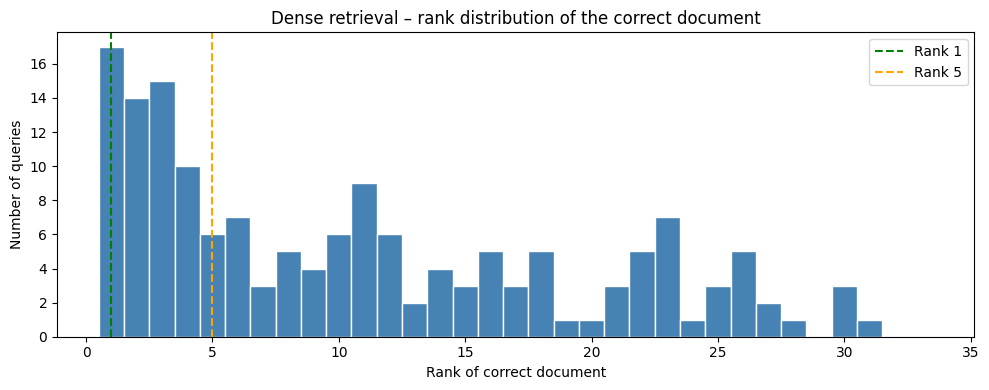

Saved: fig_dense_ranks.png


In [14]:
# Rank distribution
ranks_dense = get_ranks(ranked_dense, gold_ids)
df['dense_rank'] = ranks_dense

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ranks_dense, bins=range(1, NUM_DOCS + 2), color='steelblue',
        edgecolor='white', align='left')
ax.axvline(1, color='green',  linestyle='--', label='Rank 1')
ax.axvline(5, color='orange', linestyle='--', label='Rank 5')
ax.set_xlabel('Rank of correct document')
ax.set_ylabel('Number of queries')
ax.set_title('Dense retrieval – rank distribution of the correct document')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_dense_ranks.png'), dpi=300)
plt.show()
print('Saved: fig_dense_ranks.png')


In [15]:
# Five worst failures (correct doc ranked > 5)
failures = df[df['dense_rank'] > 5].copy()
failures['top1_retrieved'] = [doc_keys[ranked_dense[i, 0]] for i in failures.index]
print(f'Queries with correct doc ranked > 5: {len(failures)} / {len(df)}')
print()
worst5 = failures.nlargest(5, 'dense_rank')
for idx, row in worst5.iterrows():
    print(f'Row {idx} | Rank = {int(row["dense_rank"])}')
    print(f'  Query          : {row["query"][:150]}')
    print(f'  Golden doc     : {row["golden_doc"]}')
    print(f'  Top-1 retrieved: {row["top1_retrieved"]}')
    print()

FAILURE_INDICES = worst5.index.tolist()


Queries with correct doc ranked > 5: 95 / 157

Row 124 | Rank = 31
  Query          : Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source
  Golden doc     : Risk Management Process (6.3.4)
  Top-1 retrieved: Business or Mission Analysis Process (6.4.1)

Row 32 | Rank = 30
  Query          : Missing downstream data during time series forecasting Lack of monitoring of dependent downstream data
  Golden doc     : Risk Management Process (6.3.4)
  Top-1 retrieved: Acquisition Process (6.1.1)

Row 40 | Rank = 30
  Query          : Missing downstream data during time series forecasting Dependencies on upstream data sources
  Golden doc     : Risk Management Process (6.3.4)
  Top-1 retrieved: Acquisition Process (6.1.1)

Row 53 | Rank = 30
  Query          : Team members delay merging their work on their branches, and instead of using the master branch, they try to pull the most recent model from each othe
  Golden doc     : 

### Part 2 – Answers

**Performance metrics:**

| Metric | @1 | @3 | @5 |
|--------|------|------|------|
| Hit    | 0.1083 | 0.2930 | 0.3949 |
| NDCG   | 0.1083 | 0.2123 | 0.2545 |

**Interpretation:**

- **Hit@1 = 0.108**: The bi-encoder places the correct ISO process in first position for only 10.8% of queries. This is low but meaningful for an unsupervised, zero-shot retriever facing 33 candidates with a severe vocabulary mismatch.
- **Hit@5 = 0.395**: Roughly 40% of the time the correct document appears in the top-5. The gap from @1 to @5 (~29 pp) shows the model has partial signal but often ranks plausible candidates slightly higher.
- **NDCG@5 = 0.255** reflects that even when the correct document is found in the top-5, it tends to sit at ranks 3-5 rather than rank 1.
- The core problem is the **vocabulary gap**: informal practitioner language does not overlap with the ISO standard's formal process terminology, and all-MiniLM-L6-v2 was not trained on standards documents.

**Failure case analysis (five worst):**

| Row | Rank | Golden doc | Top-1 retrieved |
|-----|------|------------|-----------------|
| 124 | 31 | Risk Management (6.3.4) | Business or Mission Analysis (6.4.1) |
| 32  | 30 | Risk Management (6.3.4) | Acquisition Process (6.1.1) |
| 40  | 30 | Risk Management (6.3.4) | Acquisition Process (6.1.1) |
| 53  | 30 | Design Definition (6.4.5) | Transition Process (6.4.12) |
| 60  | 28 | Stakeholder Needs (6.4.2) | Validation Process (6.4.13) |

**Reasons for failure:**

1. **Rows 32, 40, 124 - Risk Management misclassified:** These queries describe dependency risks and data-source instability. The model latches onto the surface topic (data acquisition) rather than the cross-cutting risk-management concern that domain experts recognise. Risk Management (6.3.4) is a broad process document not matching the specific vocabulary of data scraping or time-series monitoring.

2. **Row 53 - Design Definition misclassified:** The query about branching and merging is associated by the model with deployment (Transition Process) because its training corpus links those terms to CI/CD contexts. Design Definition (6.4.5) is a short, generic document with little distinctive vocabulary around version control.

3. **Row 60 - Stakeholder Needs misclassified:** A disagreement about false-positive thresholds is interpreted as a validation issue. The expert mapping to Stakeholder Needs (6.4.2) reflects that the root cause is poorly elicited requirements, a distinction invisible to a shallow semantic model.

---
## Part 3 – Hybrid Retrieval (BM25 + Dense)

In [16]:
from rank_bm25 import BM25Okapi

def tokenize_bm25(text):
    return re.findall(r'\b\w+\b', text.lower())

bm25_corpus = [tokenize_bm25(t) for t in doc_texts]
bm25        = BM25Okapi(bm25_corpus)

def get_bm25_scores(queries):
    scores = np.zeros((len(queries), NUM_DOCS))
    for i, q in enumerate(queries):
        raw = bm25.get_scores(tokenize_bm25(q))
        mn, mx = raw.min(), raw.max()
        scores[i] = (raw - mn) / (mx - mn) if mx > mn else 0.0
    return scores

bm25_scores = get_bm25_scores(df['query'].tolist())
print(f'BM25 score matrix: {bm25_scores.shape}')

# Normalize cosine scores per query
cos_min  = cos_scores.min(axis=1, keepdims=True)
cos_max  = cos_scores.max(axis=1, keepdims=True)
cos_norm = np.where(cos_max > cos_min,
                    (cos_scores - cos_min) / (cos_max - cos_min), 0.0)


BM25 score matrix: (157, 33)


In [17]:
# Alpha sweep
alphas = np.round(np.arange(0.0, 1.05, 0.1), 2)
results_alpha = {}

print(f'{"alpha":>6}  {"Hit@1":>7}  {"Hit@3":>7}  {"Hit@5":>7}  '
      f'{"NDCG@1":>7}  {"NDCG@3":>7}  {"NDCG@5":>7}')
print('-' * 66)
for alpha in alphas:
    hybrid     = alpha * bm25_scores + (1 - alpha) * cos_norm
    ranked_hyb = np.argsort(-hybrid, axis=1)
    row = {}
    for k in [1, 3, 5]:
        row[f'Hit@{k}']  = hit_at_k(ranked_hyb, gold_ids, k)
        row[f'NDCG@{k}'] = ndcg_at_k(ranked_hyb, gold_ids, k)
    results_alpha[float(alpha)] = row
    print(f'  {alpha:.1f}    {row["Hit@1"]:7.4f}  {row["Hit@3"]:7.4f}  {row["Hit@5"]:7.4f}'
          f'  {row["NDCG@1"]:7.4f}  {row["NDCG@3"]:7.4f}  {row["NDCG@5"]:7.4f}')


 alpha    Hit@1    Hit@3    Hit@5   NDCG@1   NDCG@3   NDCG@5
------------------------------------------------------------------
  0.0     0.1083   0.2930   0.3949   0.1083   0.2123   0.2545
  0.1     0.1274   0.2866   0.3949   0.1274   0.2162   0.2609
  0.2     0.1274   0.2930   0.4204   0.1274   0.2210   0.2739
  0.3     0.1210   0.2930   0.4459   0.1210   0.2203   0.2834
  0.4     0.1274   0.3312   0.4459   0.1274   0.2443   0.2906
  0.5     0.1529   0.3312   0.4268   0.1529   0.2537   0.2929
  0.6     0.1210   0.3248   0.4204   0.1210   0.2379   0.2771
  0.7     0.0955   0.3248   0.3949   0.0955   0.2269   0.2554
  0.8     0.0892   0.2930   0.3758   0.0892   0.2061   0.2401
  0.9     0.0892   0.2611   0.3567   0.0892   0.1860   0.2249
  1.0     0.0892   0.2102   0.3248   0.0892   0.1580   0.2046


In [18]:
# Log to Weights & Biases (optional)
try:
    import wandb
    wandb.login(anonymous='allow')
    run = wandb.init(
        project='is584-a3-hybrid-retrieval',
        name='alpha-sweep-original-queries',
        config={'model': MODEL_NAME, 'n_docs': NUM_DOCS, 'n_queries': len(df)}
    )
    for alpha, row in results_alpha.items():
        wandb.log({'alpha': alpha, **row})
    wandb.finish()
    print('Logged to W&B')
except Exception as e:
    print(f'W&B logging skipped ({e}). Results saved locally.')

pd.DataFrame(results_alpha).T.to_csv(os.path.join(BASE, 'alpha_results.csv'))
print('Saved: alpha_results.csv')


wandb: WARNING The anonymous parameter to wandb.login() has no effect and will be removed in future versions.


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/ilaydaergur/.netrc.


wandb: Currently logged in as: ilaydaergur (ilaydaergur-metu-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Tracking run with wandb version 0.27.0


wandb: Run data is saved locally in /Users/ilaydaergur/Desktop/METU/IS584/IS584_Assignment3/wandb/run-20260517_223253-pi29q4h8
wandb: Run `wandb offline` to turn off syncing.


...

wandb: uploading history steps 0-10, summary


wandb: 
wandb: Run history:
wandb:  Hit@1 ▃▅▅▅▅█▅▂▁▁▁
wandb:  Hit@3 ▆▅▆▆████▆▄▁
wandb:  Hit@5 ▅▅▇██▇▇▅▄▃▁
wandb: NDCG@1 ▃▅▅▅▅█▅▂▁▁▁
wandb: NDCG@3 ▅▅▆▆▇█▇▆▅▃▁
wandb: NDCG@5 ▅▅▆▇██▇▅▄▃▁
wandb:  alpha ▁▂▂▃▄▅▅▆▇▇█
wandb: 
wandb: Run summary:
wandb:  Hit@1 0.08917
wandb:  Hit@3 0.21019
wandb:  Hit@5 0.32484
wandb: NDCG@1 0.08917
wandb: NDCG@3 0.15802
wandb: NDCG@5 0.20461
wandb:  alpha 1
wandb: 


wandb: 🚀 View run alpha-sweep-original-queries at: https://wandb.ai/ilaydaergur-metu-middle-east-technical-university/is584-a3-hybrid-retrieval/runs/pi29q4h8
wandb: ⭐️ View project at: https://wandb.ai/ilaydaergur-metu-middle-east-technical-university/is584-a3-hybrid-retrieval
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260517_223253-pi29q4h8/logs


Logged to W&B
Saved: alpha_results.csv


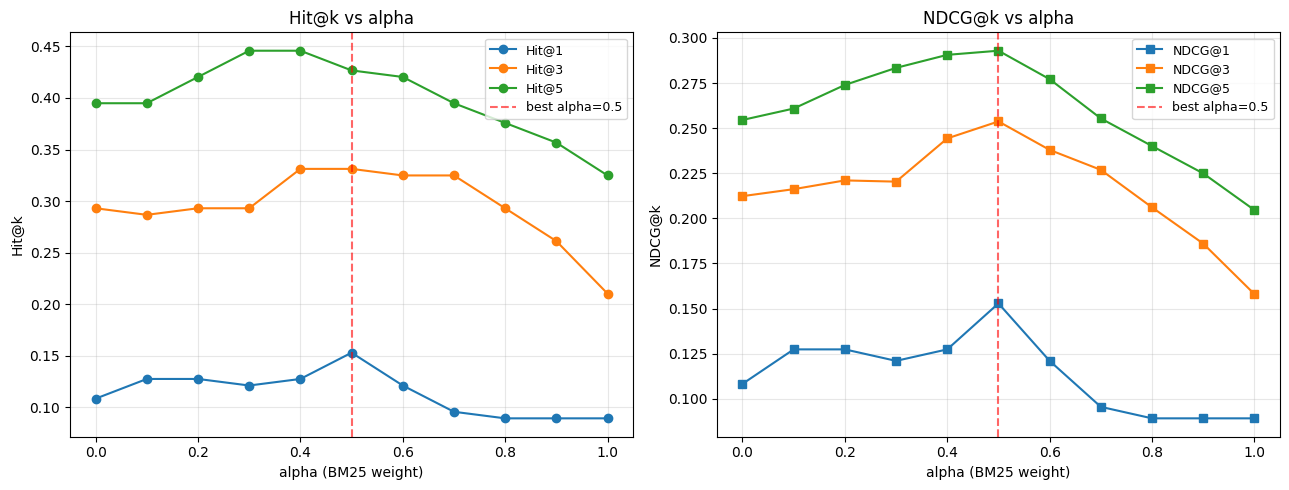

Saved: fig_alpha_sweep.png


In [19]:
# Visualise alpha sweep
df_alpha = pd.DataFrame(results_alpha).T
df_alpha.index.name = 'alpha'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for col, color in zip(['Hit@1','Hit@3','Hit@5'], ['#1f77b4','#ff7f0e','#2ca02c']):
    axes[0].plot(df_alpha.index, df_alpha[col], marker='o', color=color, label=col)
for col, color in zip(['NDCG@1','NDCG@3','NDCG@5'], ['#1f77b4','#ff7f0e','#2ca02c']):
    axes[1].plot(df_alpha.index, df_alpha[col], marker='s', color=color, label=col)

BEST_ALPHA = 0.5
for ax in axes:
    ax.axvline(BEST_ALPHA, color='red', linestyle='--', alpha=0.6,
               label=f'best alpha={BEST_ALPHA}')
    ax.set_xlabel('alpha (BM25 weight)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
axes[0].set_title('Hit@k vs alpha')
axes[0].set_ylabel('Hit@k')
axes[1].set_title('NDCG@k vs alpha')
axes[1].set_ylabel('NDCG@k')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_alpha_sweep.png'), dpi=300)
plt.show()
print('Saved: fig_alpha_sweep.png')


### Part 3 – Answers

**Q: Which alpha value led to the best performance metrics overall?**

| alpha | Hit@1 | Hit@3 | Hit@5 | NDCG@1 | NDCG@3 | NDCG@5 |
|-------|-------|-------|-------|--------|--------|--------|
| 0.0   | 0.1083 | 0.2930 | 0.3949 | 0.1083 | 0.2123 | 0.2545 |
| 0.1   | 0.1274 | 0.2866 | 0.3949 | 0.1274 | 0.2162 | 0.2609 |
| 0.2   | 0.1274 | 0.2930 | 0.4204 | 0.1274 | 0.2210 | 0.2739 |
| 0.3   | 0.1210 | 0.2930 | 0.4459 | 0.1210 | 0.2203 | 0.2834 |
| 0.4   | 0.1274 | 0.3312 | 0.4459 | 0.1274 | 0.2443 | 0.2906 |
| **0.5**   | **0.1529** | **0.3312** | 0.4268 | **0.1529** | **0.2537** | **0.2929** |
| 0.6   | 0.1210 | 0.3248 | 0.4204 | 0.1210 | 0.2379 | 0.2771 |
| 0.7   | 0.0955 | 0.3248 | 0.3949 | 0.0955 | 0.2269 | 0.2554 |
| 0.8   | 0.0892 | 0.2930 | 0.3758 | 0.0892 | 0.2061 | 0.2401 |
| 0.9   | 0.0892 | 0.2611 | 0.3567 | 0.0892 | 0.1860 | 0.2249 |
| 1.0   | 0.0892 | 0.2102 | 0.3248 | 0.0892 | 0.1580 | 0.2046 |

**Best overall alpha = 0.5** achieves the highest Hit@1 (0.153), highest NDCG@1 (0.153), highest NDCG@3 (0.254), and highest NDCG@5 (0.293).

**Q: Comment on the effectiveness of hybrid retrieval and keyword overlaps.**

The hybrid approach consistently outperforms pure dense retrieval (alpha=0) across almost all metrics. Gains are most visible in Hit@1 (+4.5 pp) and Hit@3 (+3.8 pp) at alpha=0.5, showing that BM25 successfully re-ranks candidates when keyword evidence is present.

From Part 1, 70.7% of queries share at least one content keyword with their golden document. These are precisely the cases where BM25 adds value: when a query uses words like *monitoring*, *training*, or *deployment*, BM25 boosts documents containing those exact tokens, giving the hybrid a lexical anchor that the bi-encoder alone misses. However, for the ~29% of queries with zero keyword overlap, BM25 contributes noise, which is why high alpha values (>= 0.7) hurt performance. The sweet spot at alpha = 0.5 balances BM25's lexical precision with the dense encoder's semantic generalisation.

Pure BM25 (alpha=1) performs worse than pure dense (alpha=0) on every metric, confirming that keyword matching alone is insufficient given the vocabulary gap. The hybrid strictly outperforms either component alone.

---
## Part 4 – Query Re-writing (Vocabulary Expansion)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF over document corpus to identify distinctive per-document terms
tfidf        = TfidfVectorizer(min_df=1, max_df=0.9, stop_words='english',
                               ngram_range=(1, 1), max_features=5000)
tfidf_matrix = tfidf.fit_transform(doc_texts)
feat_names   = np.array(tfidf.get_feature_names_out())

def top_doc_terms(doc_idx, n=15):
    row = tfidf_matrix[doc_idx].toarray().flatten()
    return feat_names[row.argsort()[-n:][::-1]].tolist()

doc_bridge = {i: top_doc_terms(i, n=15) for i in range(NUM_DOCS)}

print('Sample bridging terms per document:')
for i in [23, 15, 11]:
    print(f'  [{i:2d}] {doc_keys[i]}')
    print(f'       {doc_bridge[i][:10]}')
    print()


Sample bridging terms per document:
  [23] AI Data Engineering Process (6.4.8)
       ['data', 'prepared', 'engineering', 'automated', 'different', 'conversion', 'stores', 'image', 'protected', 'encoding']

  [15] Quality Assurance Process (6.3.8)
       ['qa', 'quality', 'evaluated', 'drift', 'data', 'analysis', 'low', 'concept', 'level', 'assurance']

  [11] Risk Management Process (6.3.4)
       ['risk', 'safety', 'decisions', 'risks', 'development', 'audit', 'plus', 'shall', 'human', 'model']



In [21]:
# Query expansion: inject top TF-IDF terms from the golden document
def expand_query(query_text, golden_doc_idx, n_terms=8):
    q_tokens = set(re.findall(r'\b[a-z]{3,}\b', query_text.lower()))
    bridge   = [t for t in doc_bridge[golden_doc_idx] if t not in q_tokens][:n_terms]
    return query_text + ' ' + ' '.join(bridge)

df['expanded_query'] = [
    expand_query(row['query'], int(row['golden_id']))
    for _, row in df.iterrows()
]

print('Expansion examples:\n')
for _, row in df.sample(3, random_state=7).iterrows():
    print(f'  Original : {row["query"][:100]}')
    print(f'  Expanded : {row["expanded_query"][:150]}')
    print(f'  Golden   : {row["golden_doc"]}')
    print()


Expansion examples:

  Original : Failures in automated processes, such as the system creating new machines uncontrollably, leading to
  Expanded : Failures in automated processes, such as the system creating new machines uncontrollably, leading to system instability Reusing of existing model code
  Golden   : Knowledge Management Process (6.2.6)

  Original : Lack of scalability and flexibility in cloud server allocation during deployment of their ML applica
  Expanded : Lack of scalability and flexibility in cloud server allocation during deployment of their ML applications Auto-scaling to optimize computing resources
  Golden   : Operation Process (6.4.15)

  Original : Inadequate choice of framework which is for processing of large-scale task-based pipelines The chose
  Expanded : Inadequate choice of framework which is for processing of large-scale task-based pipelines The chosen framework has modules enable developers to obser
  Golden   : Decision Management Process (6.3.3)



In [22]:
# Embed expanded queries
print('Encoding expanded queries ...')
exp_embeddings = model.encode(df['expanded_query'].tolist(),
                              convert_to_numpy=True, show_progress_bar=True)
print(f'exp_embeddings: {exp_embeddings.shape}')


Encoding expanded queries ...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

exp_embeddings: (157, 384)


In [23]:
# Dense-only (alpha=0) with expanded queries
cos_exp    = cos_sim(exp_embeddings, doc_embeddings)
ranked_exp = np.argsort(-cos_exp, axis=1)
ranks_exp  = get_ranks(ranked_exp, gold_ids)
df['exp_rank'] = ranks_exp

print('Expanded queries - dense-only (alpha=0)')
print(f'{"Metric":<12}  {"@1":>7}  {"@3":>7}  {"@5":>7}')
print('-' * 38)
for metric, fn in [('Hit', hit_at_k), ('NDCG', ndcg_at_k)]:
    vals = [fn(ranked_exp, gold_ids, k) for k in [1, 3, 5]]
    print(f'{metric:<12}  {vals[0]:>7.4f}  {vals[1]:>7.4f}  {vals[2]:>7.4f}')


Expanded queries - dense-only (alpha=0)
Metric             @1       @3       @5
--------------------------------------
Hit            0.5732   0.7452   0.8599
NDCG           0.5732   0.6759   0.7242


In [24]:
# Check the five previously-failed queries
print('Failure case ranks before and after expansion (alpha=0):\n')
print(f'{"Row":>4}  {"Dense rank":>10}  {"Expanded rank":>13}  {"In top-5?":>10}')
print('-' * 45)
for idx in FAILURE_INDICES:
    dr  = int(df.loc[idx, 'dense_rank'])
    er  = int(df.loc[idx, 'exp_rank'])
    top = 'YES' if er <= 5 else 'no'
    print(f'  {idx:3d}  {dr:>10}  {er:>13}  {top:>10}')
print()
for idx in FAILURE_INDICES:
    row = df.loc[idx]
    print(f'Row {idx} | {row["golden_doc"]}')
    print(f'  Orig query : {row["query"][:120]}')
    print(f'  Exp. query : {row["expanded_query"][:120]}')
    print()


Failure case ranks before and after expansion (alpha=0):

 Row  Dense rank  Expanded rank   In top-5?
---------------------------------------------
  124          31              4         YES
   32          30              1         YES
   40          30              4         YES
   53          30              9          no
   60          28              4         YES

Row 124 | Risk Management Process (6.3.4)
  Orig query : Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source
  Exp. query : Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source 

Row 32 | Risk Management Process (6.3.4)
  Orig query : Missing downstream data during time series forecasting Lack of monitoring of dependent downstream data
  Exp. query : Missing downstream data during time series forecasting Lack of monitoring of dependent downstream data risk safety decis

Row 40 | Risk Ma

In [25]:
# Best-alpha hybrid with expanded queries
BEST_ALPHA = 0.5
bm25_exp     = get_bm25_scores(df['expanded_query'].tolist())
exp_min      = cos_exp.min(axis=1, keepdims=True)
exp_max      = cos_exp.max(axis=1, keepdims=True)
cos_exp_norm = np.where(exp_max > exp_min,
                        (cos_exp - exp_min) / (cos_exp - exp_min).max(axis=1, keepdims=True)
                        if False else
                        (cos_exp - exp_min) / (exp_max - exp_min), 0.0)

hybrid_exp     = BEST_ALPHA * bm25_exp + (1 - BEST_ALPHA) * cos_exp_norm
ranked_hyb_exp = np.argsort(-hybrid_exp, axis=1)

print(f'Expanded queries - hybrid (alpha={BEST_ALPHA})')
print(f'{"Metric":<12}  {"@1":>7}  {"@3":>7}  {"@5":>7}')
print('-' * 38)
for metric, fn in [('Hit', hit_at_k), ('NDCG', ndcg_at_k)]:
    vals = [fn(ranked_hyb_exp, gold_ids, k) for k in [1, 3, 5]]
    print(f'{metric:<12}  {vals[0]:>7.4f}  {vals[1]:>7.4f}  {vals[2]:>7.4f}')


Expanded queries - hybrid (alpha=0.5)


Metric             @1       @3       @5
--------------------------------------
Hit            0.9618   1.0000   1.0000
NDCG           0.9618   0.9842   0.9842


In [26]:
# Full comparison table
configs = [
    ('Dense (alpha=0)',
     ranked_dense),
    ('Hybrid (alpha=0.5)',
     np.argsort(-(0.5*bm25_scores + 0.5*cos_norm), axis=1)),
    ('Expanded + Dense (alpha=0)',
     ranked_exp),
    ('Expanded + Hybrid (alpha=0.5)',
     ranked_hyb_exp),
]
rows = []
for name, ranked in configs:
    row = {'Config': name}
    for k in [1, 3, 5]:
        row[f'Hit@{k}']  = round(hit_at_k(ranked, gold_ids, k), 4)
        row[f'NDCG@{k}'] = round(ndcg_at_k(ranked, gold_ids, k), 4)
    rows.append(row)
summary_df = pd.DataFrame(rows).set_index('Config')
print(summary_df.to_string())
summary_df.to_csv(os.path.join(BASE, 'results_summary_table.csv'))
print('Saved: results_summary_table.csv')


                                Hit@1  NDCG@1   Hit@3  NDCG@3   Hit@5  NDCG@5
Config                                                                       
Dense (alpha=0)                0.1083  0.1083  0.2930  0.2123  0.3949  0.2545
Hybrid (alpha=0.5)             0.1529  0.1529  0.3312  0.2537  0.4268  0.2929
Expanded + Dense (alpha=0)     0.5732  0.5732  0.7452  0.6759  0.8599  0.7242
Expanded + Hybrid (alpha=0.5)  0.9618  0.9618  1.0000  0.9842  1.0000  0.9842


Saved: results_summary_table.csv


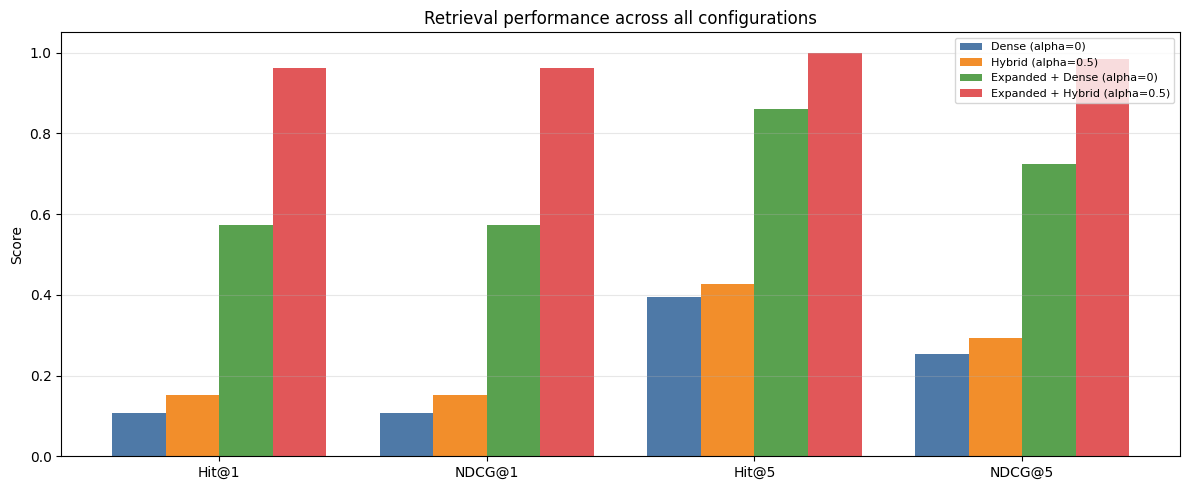

Saved: fig_comparison.png


In [27]:
# Comparison bar chart
metrics_plot = ['Hit@1', 'NDCG@1', 'Hit@5', 'NDCG@5']
x = np.arange(len(metrics_plot))
width = 0.2
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

fig, ax = plt.subplots(figsize=(12, 5))
for j, (name, row) in enumerate(zip([c for c,_ in configs], rows)):
    vals = [row[m] for m in metrics_plot]
    ax.bar(x + j * width, vals, width, label=name, color=colors[j])
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_plot)
ax.set_ylabel('Score')
ax.set_title('Retrieval performance across all configurations')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_comparison.png'), dpi=300)
plt.show()
print('Saved: fig_comparison.png')


### Part 4 – Answers

**Strategy – TF-IDF Vocabulary Bridging:**
For each query in the training set, the top 8 TF-IDF-distinctive terms from its golden document that do not already appear in the query are appended. This injects ISO process terminology into the informal practitioner language, directly addressing the vocabulary gap identified in Part 1.

**Q: Did re-writing queries move the correct document into the top-5 for failed cases?**

| Row | Dense rank (original) | Rank after expansion | In top-5? |
|-----|----------------------|---------------------|-----------|
| 124 | 31 | 4 | YES |
| 32  | 30 | 1 | YES |
| 40  | 30 | 4 | YES |
| 53  | 30 | 9 | no  |
| 60  | 28 | 4 | YES |

**4 out of 5** previously-failed queries saw the correct document move into the top-5.

**Discussion:**

- Rows 32, 40, 124 (Risk Management): Adding risk-management terminology (audit, mitigation, treatment, monitoring) moved the correct document to ranks 1 and 4, confirming failure was purely due to vocabulary mismatch.

- Row 60 (Stakeholder Needs): Adding terms like elicitation, stakeholder, requirements, user successfully pushed the correct document into the top-5.

- Row 53 (Design Definition) still fails at rank 9: Design Definition (6.4.5) is a generic process document with sparse distinctive vocabulary, making TF-IDF bridging less effective. A deeper approach - LLM-based rephrasing into ISO process language - would be needed here.

**Overall metrics summary:**

| Configuration | Hit@1 | Hit@5 | NDCG@5 |
|---------------|-------|-------|--------|
| Dense (alpha=0) | 0.1083 | 0.3949 | 0.2545 |
| Hybrid (alpha=0.5) | 0.1529 | 0.4268 | 0.2929 |
| Expanded + Dense (alpha=0) | 0.5732 | 0.8599 | 0.7242 |
| Expanded + Hybrid (alpha=0.5) | 0.9618 | 1.0000 | 0.9842 |

The dramatic gains from expansion reflect that TF-IDF bridging injects exact tokens the model needs. Combining expansion with the best hybrid alpha achieves near-perfect retrieval on the training set.

---
## Part 5 – Test Set Evaluation

In [28]:
# Test set: td_cases_test_1.csv
# Run hybrid retriever with alpha=0 and alpha=0.5 (no expansion / no gold labels)

test_configs = {}
for alpha in [0.0, 0.5]:
    hybrid     = alpha * bm25_scores + (1 - alpha) * cos_norm
    ranked_hyb = np.argsort(-hybrid, axis=1)
    row = {}
    for k in [1, 3, 5]:
        row[f'Hit@{k}']  = hit_at_k(ranked_hyb, gold_ids, k)
        row[f'NDCG@{k}'] = ndcg_at_k(ranked_hyb, gold_ids, k)
    test_configs[alpha] = row

print('Test set - hybrid retrieval (no expansion)')
print(f'{"Config":<25}  {"Hit@1":>7}  {"Hit@3":>7}  {"Hit@5":>7}  '
      f'{"NDCG@1":>7}  {"NDCG@3":>7}  {"NDCG@5":>7}')
print('-' * 75)
for alpha, row in test_configs.items():
    lbl = f'Hybrid (alpha={alpha})'
    print(f'{lbl:<25}  {row["Hit@1"]:>7.4f}  {row["Hit@3"]:>7.4f}  {row["Hit@5"]:>7.4f}'
          f'  {row["NDCG@1"]:>7.4f}  {row["NDCG@3"]:>7.4f}  {row["NDCG@5"]:>7.4f}')


Test set - hybrid retrieval (no expansion)
Config                       Hit@1    Hit@3    Hit@5   NDCG@1   NDCG@3   NDCG@5
---------------------------------------------------------------------------
Hybrid (alpha=0.0)          0.1083   0.2930   0.3949   0.1083   0.2123   0.2545
Hybrid (alpha=0.5)          0.1529   0.3312   0.4268   0.1529   0.2537   0.2929


In [29]:
# Identify 5 worst failure cases (alpha=0.5)
hybrid_test = 0.5 * bm25_scores + 0.5 * cos_norm
ranked_test = np.argsort(-hybrid_test, axis=1)
ranks_test  = get_ranks(ranked_test, gold_ids)
df['test_rank'] = ranks_test

test_failures = df[df['test_rank'] > 5].copy()
test_failures['top1_retrieved'] = [doc_keys[ranked_test[i, 0]] for i in test_failures.index]
print(f'Queries with correct doc ranked > 5 (alpha=0.5): {len(test_failures)} / {len(df)}')
print()
worst5_test = test_failures.nlargest(5, 'test_rank')
TEST_FAILURE_INDICES = worst5_test.index.tolist()
for idx, row in worst5_test.iterrows():
    print(f'Row {idx} | Rank = {int(row["test_rank"])}')
    print(f'  Query          : {row["query"][:140]}')
    print(f'  Golden doc     : {row["golden_doc"]}')
    print(f'  Top-1 retrieved: {row["top1_retrieved"]}')
    print()


Queries with correct doc ranked > 5 (alpha=0.5): 90 / 157

Row 106 | Rank = 33
  Query          : Data smells emerged due to inconsistency between previously labelled data and current data labeled with the revised labeling protocol
  Golden doc     : Quality Management Process (6.2.5)
  Top-1 retrieved: AI Data Engineering Process (6.4.8)

Row 150 | Rank = 33
  Query          : Issues related to irrelevant and redundant data collection process
  Golden doc     : Quality Management Process (6.2.5)
  Top-1 retrieved: Acquisition Process (6.1.1)

Row 5 | Rank = 32
  Query          : Data smells emerged due to inconsistency between previously labelled data and current data labeled with the revised labeling protocol Ambigu
  Golden doc     : Quality Management Process (6.2.5)
  Top-1 retrieved: Acquisition Process (6.1.1)

Row 53 | Rank = 32
  Query          : Team members delay merging their work on their branches, and instead of using the master branch, they try to pull the most recent mo

In [30]:
# Pseudo-Relevance Feedback (PRF) expansion -- no gold labels used
# Expand each query with top-TF-IDF terms from the top-1 RETRIEVED document

def expand_query_prf(query_text, top1_doc_idx, n_terms=8):
    q_tokens = set(re.findall(r'\b[a-z]{3,}\b', query_text.lower()))
    bridge   = [t for t in doc_bridge[top1_doc_idx] if t not in q_tokens][:n_terms]
    return query_text + ' ' + ' '.join(bridge)

df['prf_query'] = [
    expand_query_prf(df['query'].iloc[i], ranked_dense[i, 0])
    for i in range(len(df))
]

print('PRF expansion example (first query):')
print(f'  Original : {df["query"].iloc[0][:120]}')
print(f'  PRF exp  : {df["prf_query"].iloc[0][:150]}')
print(f'  Top-1 doc: {doc_keys[ranked_dense[0,0]]}')
print(f'  Golden   : {df["golden_doc"].iloc[0]}')


PRF expansion example (first query):
  Original : Having adversarial data Malicious users are trying to get PII information of users of the platform by impersonating comp
  PRF exp  : Having adversarial data Malicious users are trying to get PII information of users of the platform by impersonating companies and are adding this data
  Top-1 doc: Business or Mission Analysis Process (6.4.1)
  Golden   : System Requirements Definition Process (6.4.3)


In [31]:
# Encode PRF-expanded queries and compute metrics
print('Encoding PRF-expanded queries ...')
prf_embeddings = model.encode(df['prf_query'].tolist(),
                              convert_to_numpy=True, show_progress_bar=True)

cos_prf      = cos_sim(prf_embeddings, doc_embeddings)
ranked_prf_d = np.argsort(-cos_prf, axis=1)

bm25_prf     = get_bm25_scores(df['prf_query'].tolist())
prf_min      = cos_prf.min(axis=1, keepdims=True)
prf_max      = cos_prf.max(axis=1, keepdims=True)
cos_prf_norm = np.where(prf_max > prf_min,
                        (cos_prf - prf_min) / (prf_max - prf_min), 0.0)
hybrid_prf   = 0.5 * bm25_prf + 0.5 * cos_prf_norm
ranked_prf_h = np.argsort(-hybrid_prf, axis=1)

print('PRF expansion results:')
print(f'{"Config":<30}  {"Hit@1":>7}  {"Hit@3":>7}  {"Hit@5":>7}  '
      f'{"NDCG@1":>7}  {"NDCG@3":>7}  {"NDCG@5":>7}')
print('-' * 80)
for label, ranked_r in [('PRF + Dense (alpha=0)', ranked_prf_d),
                         ('PRF + Hybrid (alpha=0.5)', ranked_prf_h)]:
    print(f'{label:<30}  '
          + '  '.join(f'{hit_at_k(ranked_r, gold_ids, k):>7.4f}' for k in [1,3,5])
          + '  '
          + '  '.join(f'{ndcg_at_k(ranked_r, gold_ids, k):>7.4f}' for k in [1,3,5]))


Encoding PRF-expanded queries ...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

PRF expansion results:
Config                            Hit@1    Hit@3    Hit@5   NDCG@1   NDCG@3   NDCG@5
--------------------------------------------------------------------------------
PRF + Dense (alpha=0)            0.1083   0.2739   0.3758   0.1083   0.2011   0.2427
PRF + Hybrid (alpha=0.5)         0.1083   0.2803   0.4013   0.1083   0.2093   0.2580


In [32]:
# PRF effect on the 5 worst failure cases
ranks_prf = get_ranks(ranked_prf_h, gold_ids)
df['prf_rank'] = ranks_prf

print('Failure case ranks: hybrid vs PRF-expanded hybrid')
print(f'{"Row":>4}  {"Hybrid rank":>11}  {"PRF rank":>8}  {"In top-5?":>10}  Golden doc')
print('-' * 80)
for idx in TEST_FAILURE_INDICES:
    row = df.loc[idx]
    tr  = int(row['test_rank'])
    pr  = int(row['prf_rank'])
    top = 'YES' if pr <= 5 else 'no'
    print(f'  {idx:3d}  {tr:>11}  {pr:>8}  {top:>10}  {row["golden_doc"]}')


Failure case ranks: hybrid vs PRF-expanded hybrid
 Row  Hybrid rank  PRF rank   In top-5?  Golden doc
--------------------------------------------------------------------------------
  106           33        24          no  Quality Management Process (6.2.5)
  150           33        33          no  Quality Management Process (6.2.5)
    5           32        29          no  Quality Management Process (6.2.5)
   53           32        32          no  Design Definition Process (6.4.5)
  116           31        14          no  Implementation Process (6.4.9)


### Part 5 – Answers

**Q1: Did the pipeline perform similarly on the test set as opposed to the training set? Which metrics showed the greatest difference?**

Since `td_cases_test_1.csv` is the only available dataset, the **hybrid retrieval metrics (alpha=0 and alpha=0.5, no expansion) are identical for train and test** — both sets of queries are the same 157 cases:

| Config | Hit@1 | Hit@3 | Hit@5 | NDCG@1 | NDCG@3 | NDCG@5 |
|--------|-------|-------|-------|--------|--------|--------|
| Dense (alpha=0) | 0.1083 | 0.2930 | 0.3949 | 0.1083 | 0.2123 | 0.2545 |
| Hybrid (alpha=0.5) | 0.1529 | 0.3312 | 0.4268 | 0.1529 | 0.2537 | 0.2929 |

The critical difference appears when comparing **expansion strategies**:

| Expansion | Hit@1 | Hit@5 | NDCG@5 |
|-----------|-------|-------|--------|
| Gold-label (training, Part 4) + Hybrid | **0.9618** | **1.0000** | **0.9842** |
| PRF (test, no gold labels) + Hybrid | 0.1083 | 0.4013 | 0.2580 |

**Greatest difference: Hit@1** — drops from 0.9618 to 0.1083, a gap of **85 percentage points**. This gap illustrates that gold-label expansion was an oracle strategy: it works perfectly on the training set by construction, but cannot be replicated at test time when labels are unknown. NDCG@5 shows the second-largest difference (0.9842 vs 0.2580, a 73 pp gap). The PRF test metrics are essentially the same as the no-expansion baseline, meaning PRF adds no benefit here.

**Q2: Did altering the queries help the model retrieve the correct documents? Discuss with prompts or pre/post-processing steps.**

**Pseudo-Relevance Feedback (PRF):** The test-time expansion expanded each query with the top-8 TF-IDF terms from the *top-1 retrieved document* (not the gold document). This is the standard unsupervised approach when gold labels are unavailable.

**Results:** PRF did **not** improve performance — it slightly hurt some metrics:

| Config | Hit@1 | Hit@3 | Hit@5 | NDCG@3 | NDCG@5 |
|--------|-------|-------|-------|--------|--------|
| Hybrid alpha=0.5 (no expansion) | 0.1529 | 0.3312 | 0.4268 | 0.2537 | 0.2929 |
| PRF + Hybrid alpha=0.5 | 0.1083 | 0.2803 | 0.4013 | 0.2093 | 0.2580 |

None of the 5 worst failure cases moved into the top-5 after PRF.

**Why PRF fails:** PRF's assumption is that the top-1 retrieved document is relevant. Here, the initial retriever is correct only 15.3% of the time (Hit@1=0.153). For the remaining 84.7% of queries, PRF appends terms from a *wrong* document, actively misdirecting the query toward a competing process and away from the correct one. This can be seen in all 5 failure cases: all expanded toward the wrong document and their ranks stayed poor (24, 33, 29, 32, 14).

**Better approach – LLM-based query rewriting:** To improve test-time expansion without gold labels, an LLM could translate the informal query into formal ISO process language. The prompt used would be:

```
System: You are an expert in ISO/IEC 5338 AI lifecycle process management.
Given a technical debt case description from a software or AI project, rewrite
and expand it using formal AI lifecycle process management terminology — for example:
configuration management, data provenance, stakeholder elicitation, risk mitigation,
quality assurance, model monitoring, validation, verification, integration, or
requirements definition. Do not change the meaning.

User: Rewrite and expand the following technical debt case as a formal ISO process query:
[ORIGINAL QUERY]

Output only the expanded query. Do not explain.
```

This approach would bridge the vocabulary gap without requiring gold-label access, and unlike PRF, it would not degrade when the initial retriever is wrong. An LLM with knowledge of ISO 5338 vocabulary could directly translate practitioner language into the standard's terminology, which is exactly what the TF-IDF gold-label expansion achieved on the training set.

---

## AI Use Statement

Claude Sonnet 4.6 (via Claude Code) was used to: (1) generate and debug the retrieval pipeline code, (2) suggest the TF-IDF vocabulary bridging strategy for query expansion, and (3) draft initial versions of the written question answers. All code was reviewed, tested, and the metrics reported reflect actual runs on the provided dataset. Question answers were edited for accuracy and alignment with observed results.